In [144]:
import torch
import matplotlib.pyplot as plt
from t1_pancast10_interpolation import t1Core2MapModel
from t3_pancast10_interpolation import t3Core2MapModel
import numpy as np

In [145]:
# === Load the checkpoint for t1 ===
checkpoint_path_t1 = "/home/users/mendrika/pancast-self/9bmd4qbe/checkpoints/best-core2map.ckpt"
model_t1 = t1Core2MapModel.load_from_checkpoint(checkpoint_path_t1)
model_t1.eval()
model_t1.freeze()

# === Load the checkpoint for t3 ===
checkpoint_path_t3 = "/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/pancast-t3/zwluy290/checkpoints/best-core2map.ckpt"
model_t3 = t3Core2MapModel.load_from_checkpoint(checkpoint_path_t3)
model_t3.eval()
model_t3.freeze()

In [146]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_sample(shard_dir: str, lead_time: int, idx: int):
    path = f"{shard_dir}/t{lead_time}-shard-test-025_proc.pt"
    shard = torch.load(path, map_location="cpu")
    x = shard["inputs"][idx].unsqueeze(0).float().to(device)
    y = shard["targets"][idx].unsqueeze(0).float()
    return x, y

# === Specify different shard base directories ===
shard_dir_t1 = "/work/scratch-nopw2/mrakotomanga/eps/pancast-shard-processed/t1/test_512"
shard_dir_t3 = "/work/scratch-nopw2/mrakotomanga/eps/pancast-shard-processed-ds/t3/test_512"

# === Load same-index sample from t1 and t3 folders ===
idx = 345

x_t1, y_t1 = load_sample(shard_dir_t1, lead_time=1, idx=idx)
x_t3, y_t3 = load_sample(shard_dir_t3, lead_time=3, idx=idx)

In [147]:
# === Run inference ===
with torch.no_grad():
    pred_t1 = torch.sigmoid(model_t1(x_t1)).squeeze().cpu().numpy()
    pred_t3 = torch.sigmoid(model_t3(x_t3)).squeeze().cpu().numpy()
    y_t1_np = y_t1.squeeze(0).cpu().numpy()
    y_t3_np = y_t3.squeeze(0).cpu().numpy()

# === Flip vertically for map convention ===
pred_t1 = np.flipud(pred_t1)
pred_t3 = np.flipud(pred_t3)
y_t1_np = np.flipud(y_t1_np)
y_t3_np = np.flipud(y_t3_np)

# === Plot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=1200)

# Row 1: Predictions
im00 = axes[0, 0].imshow(pred_t1, cmap="plasma")
axes[0, 0].set_title("Prediction t1")
axes[0, 0].axis("off")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(pred_t3, cmap="plasma")
axes[0, 1].set_title("Prediction t3")
axes[0, 1].axis("off")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Row 2: Ground Truths
im10 = axes[1, 0].imshow(y_t1_np, cmap="viridis")
axes[1, 0].set_title("Ground Truth t1")
axes[1, 0].axis("off")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(y_t3_np, cmap="viridis")
axes[1, 1].set_title("Ground Truth t3")
axes[1, 1].axis("off")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# Compute FSS

In [148]:
import numpy as np
from scipy.ndimage import uniform_filter

def compute_fss(pred_np, y_np, threshold=0.2, window=9):
    # Binarise
    pred_bin = (pred_np >= threshold).astype(np.float32)
    y_bin = (y_np >= threshold).astype(np.float32)

    # Smooth using uniform filter
    kernel_size = window
    pred_smooth = uniform_filter(pred_bin, size=kernel_size, mode="constant")
    y_smooth = uniform_filter(y_bin, size=kernel_size, mode="constant")

    # Compute FSS
    mse_f = np.mean((pred_smooth - y_smooth) ** 2)
    mse_ref = np.mean(pred_smooth ** 2 + y_smooth ** 2)

    fss = 1.0 - (mse_f / (mse_ref + 1e-8))  # avoid division by zero

    return fss

# Compute FSS scores
fss_t1 = compute_fss(pred_t1, y_t1_np, threshold=0.2, window=9)
fss_t3 = compute_fss(pred_t3, y_t3_np, threshold=0.2, window=9)

print(f"FSS (t1): {fss_t1:.3f}")
print(f"FSS (t3): {fss_t3:.3f}")


FSS (t1): 0.644
FSS (t3): 0.000


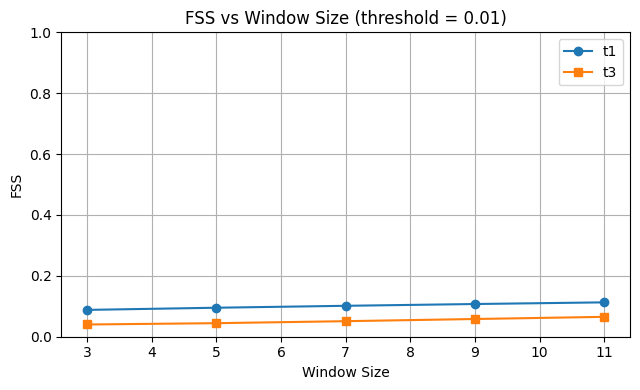

In [149]:

# Parameters
threshold = 0.01
window_sizes = [3, 5, 7, 9, 11]

# Compute FSS for t1 and t3
fss_t1 = [compute_fss(pred_t1, y_t1_np, threshold=threshold, window=w) for w in window_sizes]
fss_t3 = [compute_fss(pred_t3, y_t3_np, threshold=threshold, window=w) for w in window_sizes]

# Plot
plt.figure(figsize=(6.5, 4))
plt.plot(window_sizes, fss_t1, marker='o', label="t1")
plt.plot(window_sizes, fss_t3, marker='s', label="t3")
plt.title(f"FSS vs Window Size (threshold = {threshold})")
plt.xlabel("Window Size")
plt.ylabel("FSS")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()